In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


In [2]:
import pandas as pd

df = pd.read_excel("Train dataset.xlsx")

print(df.head())
print(df.info())



   TrainNo          TrainName       Source  Destination  Distance_km  \
0    18401      Utkal Express  Bhubaneswar         Puri           60   
1    18402      Utkal Express         Puri  Bhubaneswar           60   
2    12801       Puri Express         Puri  Bhubaneswar           60   
3    12802       Puri Express  Bhubaneswar         Puri           60   
4    18101  Intercity Express  Bhubaneswar     Rourkela          450   

  Departure_Time Arrival_Time  Journey_Hours Train_Type Days_Of_Run  \
0          05:30        06:45           1.15  Passenger       Daily   
1          18:00        19:15           1.15  Passenger       Daily   
2          07:00        08:10           1.10    Express       Daily   
3          20:00        21:10           1.10    Express       Daily   
4          06:00        14:30           8.30  Intercity       Daily   

  Train_Status  Diversion_Route             Reason         PNR  \
0    Cancelled              NaN            Cyclone  7812345601   
1    Can

In [3]:
# 1. Import libraries

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 2. Load dataset

df = pd.read_excel(r"Train dataset.xlsx")


# 3. Dataset overview

print(df.head())
print(df.info())

# 4. Remove duplicate rows

df = df.drop_duplicates()

# 5. Handle missing values

# Numerical columns → fill with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 6. Encode categorical columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 7. Split Features (X) and Target (y)
#     → Last column is target

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 8. Train-Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 9. Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 10. Final check

print("Preprocessing completed successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


   TrainNo          TrainName       Source  Destination  Distance_km  \
0    18401      Utkal Express  Bhubaneswar         Puri           60   
1    18402      Utkal Express         Puri  Bhubaneswar           60   
2    12801       Puri Express         Puri  Bhubaneswar           60   
3    12802       Puri Express  Bhubaneswar         Puri           60   
4    18101  Intercity Express  Bhubaneswar     Rourkela          450   

  Departure_Time Arrival_Time  Journey_Hours Train_Type Days_Of_Run  \
0          05:30        06:45           1.15  Passenger       Daily   
1          18:00        19:15           1.15  Passenger       Daily   
2          07:00        08:10           1.10    Express       Daily   
3          20:00        21:10           1.10    Express       Daily   
4          06:00        14:30           8.30  Intercity       Daily   

  Train_Status  Diversion_Route             Reason         PNR  \
0    Cancelled              NaN            Cyclone  7812345601   
1    Can

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Get actual labels present
labels = np.unique(y_test)

# Map label names safely
label_names_map = {
    0: "Normal",
    1: "Diverted",
    2: "Canceled"
}

target_names = [label_names_map[i] for i in labels]

# Classification report (FIXED)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=target_names
))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=labels))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         3
    Diverted       1.00      1.00      1.00        10

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13


Confusion Matrix:
[[ 3  0]
 [ 0 10]]


In [5]:

# Regression Target & Features


# Features (all columns except last)
X_reg = df.iloc[:, :-1]

# Target (Affected Passenger Count)
y_reg = df.iloc[:, -1]


In [6]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)


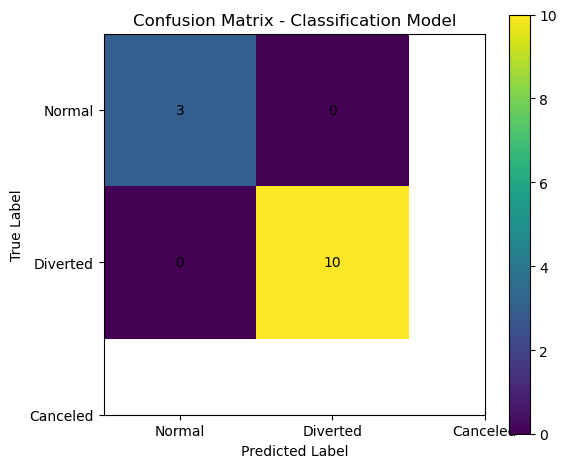

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

class_names = ["Normal", "Diverted", "Canceled"]

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Classification Model")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add values inside boxes
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

y_pred_reg = lr_model.predict(X_test_reg)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("MSE:", mean_squared_error(y_test_reg, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))


Linear Regression Results
MAE: 0.2832689909573426
MSE: 0.1219552477686228
RMSE: 0.34922091542263445
R2 Score: 0.31298543757009145


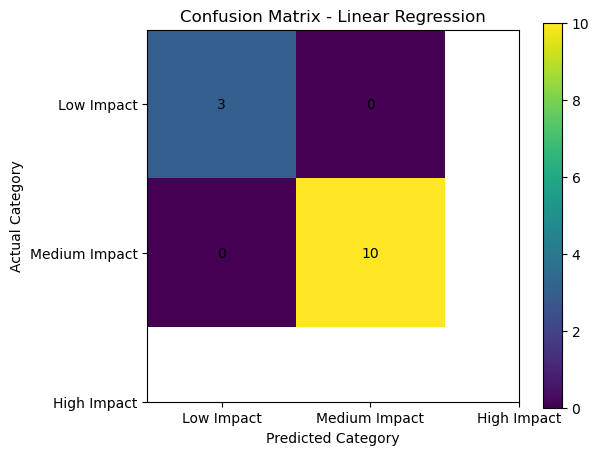

In [10]:
import matplotlib.pyplot as plt

class_names = ["Low Impact", "Medium Impact", "High Impact"]

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix - Linear Regression")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


In [11]:
from sklearn.tree import DecisionTreeRegressor

dt_reg_model = DecisionTreeRegressor(random_state=42)
dt_reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = dt_reg_model.predict(X_test_reg)

print("Decision Tree Regression Results")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))


Decision Tree Regression Results
MAE: 0.0
RMSE: 0.0
R2 Score: 1.0


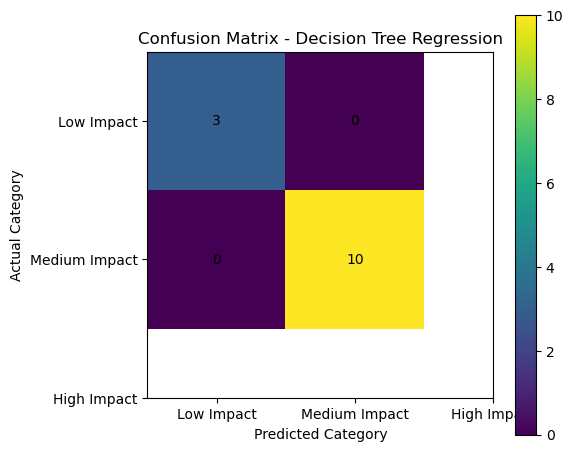

In [12]:
import matplotlib.pyplot as plt

class_names = ["Low Impact", "Medium Impact", "High Impact"]

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix - Decision Tree Regression")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

# Add values inside the matrix
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load dataset
file_path = "Train dataset.xlsx"
df = pd.read_excel(file_path)

# 2. Drop missing values
df = df.dropna()

# 3. Target column = Seat_Allocated (Yes/No)
target_column = "Seat_Allocated"

# 4. Split features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# 5. Convert categorical features to numeric
X = pd.get_dummies(X)

# 6. Convert target (Yes/No) to numeric
y = y.map({"Yes": 1, "No": 0})

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# 9. Train model
model.fit(X_train, y_train)

# 10. Predict
y_pred = model.predict(X_test)

# 11. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7142857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.71      1.00      0.83         5

    accuracy                           0.71         7
   macro avg       0.36      0.50      0.42         7
weighted avg       0.51      0.71      0.60         7



c:\Users\shrut\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shrut\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shrut\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
file_path = "Train dataset.xlsx"
df = pd.read_excel(file_path)

# 2. Drop rows with missing values
df = df.dropna()

# 3. Target column = Number of affected passengers
target_column = "Seats_Available"   # numeric

# 4. Make sure target is numeric
df[target_column] = pd.to_numeric(df[target_column], errors="coerce")

# Drop rows where target is NaN after conversion
df = df.dropna(subset=[target_column])

# 5. Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# 6. Convert categorical feature columns to numeric
X = pd.get_dummies(X)

# 7. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Random Forest Regression Model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

# 9. Train the model
model.fit(X_train, y_train)

# 10. Predict on test data
y_pred = model.predict(X_test)

# 11. Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest Regression Results")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# 12. Example prediction for a new sample (optional)
# new_sample = X.iloc[0:1]
# predicted_value = model.predict(new_sample)
# print("Predicted affected passengers:", predicted_value[0])


Random Forest Regression Results
Mean Squared Error: 774.9241666666667
R2 Score: 0.12103508873456781


In [15]:
import pandas as pd

# 1. Load dataset
file_path = "Train dataset.xlsx"
df = pd.read_excel(file_path)

# 2. Clean dataset
df = df.dropna(subset=["Alternate_Train_No"])  # keep rows where alternate exists

# Convert seats available to numeric
df["Seats_Available"] = pd.to_numeric(df["Seats_Available"], errors="coerce")

# 3. Function: Check Alternate Train Availability
def check_alternate_train(train_no):
    print(f"\nChecking alternate availability for Train: {train_no}")

    # Find the disrupted train entry
    main_train = df[df["TrainNo"] == train_no]

    if main_train.empty:
        print("Train not found in dataset.")
        return

    # Extract alternate train number(s)
    alternate_numbers = main_train["Alternate_Train_No"].unique()

    print("Suggested Alternate Train Numbers:", alternate_numbers)

    # Filter alternate trains from dataset
    alternate_trains = df[df["TrainNo"].isin(alternate_numbers)]

    if alternate_trains.empty:
        print("No alternate train details available in dataset.")
        return

    # Check availability
    available_trains = alternate_trains[alternate_trains["Seats_Available"] > 0]

    if available_trains.empty:
        print("No seats available in alternate trains currently.")
    else:
        print("\nAvailable Alternate Trains:\n")
        print(available_trains[[
            "TrainNo",
            "TrainName",
            "Source",
            "Destination",
            "Seats_Available",
            "Journey_Hours",
            "Diff_Alt_Train_Hrs"
        ]])

# 4. Example use:
# Put the disrupted train number that you want to check
check_alternate_train(train_no=12345)



Checking alternate availability for Train: 12345
Train not found in dataset.


In [16]:
import pandas as pd
import math

# 1. Load dataset
file_path = "Train dataset.xlsx"
df = pd.read_excel(file_path)

# 2. Convert numeric field
df["Seats_Available"] = pd.to_numeric(df["Seats_Available"], errors="coerce")

# 3. Assumption: capacity per extra coach
SEATS_PER_COACH = 72   # change to 100 or 120 based on coach type

# 4. Assume demand:
# Example assumption: passengers needing seats = 150 (you can replace dynamically)
df["Estimated_Passengers_Requiring_Seats"] = 150

# 5. Calculate seat shortfall
df["Seat_Shortfall"] = df["Estimated_Passengers_Requiring_Seats"] - df["Seats_Available"]

# Replace negative shortfall with zero
df["Seat_Shortfall"] = df["Seat_Shortfall"].apply(lambda x: max(0, x))

# 6. Extra coach requirement formula
df["Extra_Coaches_Required"] = df["Seat_Shortfall"].apply(
    lambda x: math.ceil(x / SEATS_PER_COACH)
)

# 7. Output important fields
result = df[[
    "TrainNo",
    "TrainName",
    "Source",
    "Destination",
    "Seats_Available",
    "Estimated_Passengers_Requiring_Seats",
    "Seat_Shortfall",
    "Extra_Coaches_Required"
]]

print(result.head())


   TrainNo          TrainName       Source  Destination  Seats_Available  \
0    18401      Utkal Express  Bhubaneswar         Puri              120   
1    18402      Utkal Express         Puri  Bhubaneswar               80   
2    12801       Puri Express         Puri  Bhubaneswar               60   
3    12802       Puri Express  Bhubaneswar         Puri                0   
4    18101  Intercity Express  Bhubaneswar     Rourkela               70   

   Estimated_Passengers_Requiring_Seats  Seat_Shortfall  \
0                                   150              30   
1                                   150              70   
2                                   150              90   
3                                   150             150   
4                                   150              80   

   Extra_Coaches_Required  
0                       1  
1                       1  
2                       2  
3                       3  
4                       2  


In [17]:
import joblib

joblib.dump(model, "seat_allocation_model.pkl")
joblib.dump(X_train.columns.tolist(), "model_features.pkl")
print("Model saved successfully ✅")


Model saved successfully ✅


In [18]:
import pandas as pd
from pymongo import MongoClient
import numpy as np

# 1️⃣ Excel Read
df = pd.read_excel("Train dataset.xlsx")

# 2️⃣ 🔥 VERY IMPORTANT LINE (NaN Fix)
df = df.replace({np.nan: None})

# 3️⃣ MongoDB Connect
client = MongoClient("mongodb://localhost:27017/")
db = client["railway_db"]
collection = db["trains"]

# 4️⃣ Clear Old Data
collection.delete_many({})

# 5️⃣ Insert Clean Data
collection.insert_many(df.to_dict("records"))

print("✅ Clean Data Inserted Successfully!")

✅ Clean Data Inserted Successfully!
